# 🎬 OTT Platform User Behavior Analyzer
### Classification | Regression | Clustering

**Dataset:** Netflix Shows (Kaggle - shivamb/netflix-shows)  
**Goal:** Analyze user behavior → predict churn, watch time, and segment viewers into personas

---
> ⚠️ **Note:** The Kaggle dataset is content-based (movies/shows metadata). We will load it and derive/simulate realistic user behavior features from it. This is a standard and accepted approach when user-level data is unavailable.

## 📦 Step 0: Install & Import Libraries

In [1]:
# Install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Clustering models
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Step 1: Load the Netflix Dataset

**Download instructions:**
1. Go to https://www.kaggle.com/datasets/shivamb/netflix-shows
2. Download `netflix_titles.csv`
3. Place it in the same folder as this notebook

The cell below loads the file. If not found, it creates a small demo version so you can still run everything.

In [2]:
import os

if os.path.exists('netflix_titles.csv'):
    netflix_df = pd.read_csv('netflix_titles.csv')
    print(f"✅ Dataset loaded: {netflix_df.shape[0]} rows, {netflix_df.shape[1]} columns")
else:
    print("⚠️  'netflix_titles.csv' not found. Creating a demo dataset with 500 records...")
    genres = ['Drama', 'Comedy', 'Action', 'Documentary', 'Thriller', 'Romance', 'Horror', 'Sci-Fi', 'Animation', 'Crime']
    countries = ['United States', 'India', 'United Kingdom', 'Canada', 'France', 'Japan', 'South Korea']
    types = ['Movie', 'TV Show']
    ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'PG', 'G', 'NR']
    n = 500
    netflix_df = pd.DataFrame({
        'show_id': [f's{i}' for i in range(1, n+1)],
        'type': np.random.choice(types, n),
        'title': [f'Title_{i}' for i in range(1, n+1)],
        'director': [f'Director_{i}' if np.random.rand() > 0.2 else np.nan for i in range(1, n+1)],
        'country': np.random.choice(countries, n),
        'date_added': pd.date_range('2015-01-01', periods=n, freq='3D').strftime('%B %d, %Y'),
        'release_year': np.random.randint(2000, 2023, n),
        'rating': np.random.choice(ratings, n),
        'duration': [f'{np.random.randint(30,180)} min' if t=='Movie' else f'{np.random.randint(1,10)} Seasons'
                     for t in np.random.choice(types, n)],
        'listed_in': np.random.choice(genres, n),
        'description': ['Sample description'] * n
    })
    print(f"✅ Demo dataset created: {netflix_df.shape}")

netflix_df.head()

✅ Dataset loaded: 8807 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
## 🔧 Step 2: Data Preprocessing on Netflix Content Data

In [3]:
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
print(netflix_df.info())
print("\n📊 Missing Values:")
print(netflix_df.isnull().sum())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

📊 Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
liste

In [4]:
# ----- Clean the content dataset -----
df = netflix_df.copy()

# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('NR', inplace=True)
df['listed_in'].fillna('Unknown', inplace=True)

# Extract primary genre (first listed)
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

# Extract duration in minutes for Movies, seasons for TV Shows
def extract_duration(row):
    try:
        if 'Season' in str(row['duration']):
            return int(str(row['duration']).split()[0]) * 10  # approximate episodes
        elif 'min' in str(row['duration']):
            return int(str(row['duration']).split()[0])
    except:
        return np.nan
    return np.nan

df['duration_val'] = df.apply(extract_duration, axis=1)
df['duration_val'].fillna(df['duration_val'].median(), inplace=True)

# Content age (years since added)
df['content_age'] = 2024 - df['release_year']

print("✅ Netflix content data cleaned!")
print(f"Shape: {df.shape}")
df[['type','primary_genre','duration_val','content_age']].head()

✅ Netflix content data cleaned!
Shape: (8807, 15)


,type,primary_genre,duration_val,content_age
0,Movie,Documentaries,90.0,4
1,TV Show,International TV Shows,20.0,3
2,TV Show,Crime TV Shows,10.0,3
3,TV Show,Docuseries,10.0,3
4,TV Show,International TV Shows,20.0,3


---
## 🧪 Step 3: Simulate User Behavior Dataset

> Since the Kaggle dataset is content-based, we simulate a **user behavior dataset** of 5,000 users. Features are derived with realistic distributions and relationships.

**Features generated:**
- `watch_time` — total hours watched per month
- `number_of_sessions` — logins per month
- `preferred_genre` — most watched genre
- `last_login_days` — days since last login
- `subscription_type` — Basic / Standard / Premium
- `rating_given` — avg rating (1–5)
- `churn` — 0 = active, 1 = churned (our target for classification)
- Additional engineered features

In [5]:
np.random.seed(42)
N_USERS = 5000

genres = df['primary_genre'].value_counts().index.tolist()[:10]
if len(genres) < 5:
    genres = ['Drama', 'Comedy', 'Action', 'Documentary', 'Thriller', 'Romance', 'Horror', 'Sci-Fi', 'Animation', 'Crime']

subscription_types = ['Basic', 'Standard', 'Premium']
sub_weights = [0.4, 0.35, 0.25]

# --- Base user attributes ---
subscription_type = np.random.choice(subscription_types, N_USERS, p=sub_weights)
preferred_genre = np.random.choice(genres, N_USERS)

# Watch time influenced by subscription (Premium > Standard > Basic)
sub_multiplier = np.where(subscription_type == 'Premium', 1.5,
                 np.where(subscription_type == 'Standard', 1.0, 0.6))
watch_time = np.clip(np.random.normal(30, 15, N_USERS) * sub_multiplier, 1, 200)

# Sessions per month
number_of_sessions = np.clip(np.random.poisson(12, N_USERS) * sub_multiplier, 1, 90).astype(int)

# Days since last login (higher = more inactive = likely churn)
last_login_days = np.clip(np.random.exponential(15, N_USERS), 0, 90).astype(int)

# Average rating given
rating_given = np.clip(np.random.normal(3.5, 0.8, N_USERS), 1, 5)

# Device type
device_type = np.random.choice(['Mobile', 'TV', 'Laptop', 'Tablet'], N_USERS, p=[0.4, 0.3, 0.2, 0.1])

# Tenure (months as subscriber)
tenure_months = np.random.randint(1, 60, N_USERS)

# Number of profiles on account
num_profiles = np.random.choice([1, 2, 3, 4, 5], N_USERS, p=[0.3, 0.3, 0.2, 0.15, 0.05])

# Content type preference
content_pref = np.random.choice(['Movie', 'TV Show', 'Both'], N_USERS, p=[0.35, 0.35, 0.30])

# --- Churn Logic (realistic rules) ---
# High churn probability if: low watch time, high last_login_days, Basic plan, low rating
churn_score = (
    (last_login_days > 30).astype(int) * 0.35 +
    (watch_time < 10).astype(int) * 0.25 +
    (rating_given < 2.5).astype(int) * 0.20 +
    (subscription_type == 'Basic').astype(int) * 0.10 +
    (number_of_sessions < 4).astype(int) * 0.10
)
churn_prob = churn_score + np.random.normal(0, 0.05, N_USERS)
churn = (churn_prob > 0.35).astype(int)

# --- Assemble DataFrame ---
user_df = pd.DataFrame({
    'user_id': [f'U{i:05d}' for i in range(N_USERS)],
    'subscription_type': subscription_type,
    'preferred_genre': preferred_genre,
    'watch_time': np.round(watch_time, 2),
    'number_of_sessions': number_of_sessions,
    'last_login_days': last_login_days,
    'rating_given': np.round(rating_given, 1),
    'device_type': device_type,
    'tenure_months': tenure_months,
    'num_profiles': num_profiles,
    'content_pref': content_pref,
    'churn': churn
})

print(f"✅ User behavior dataset created: {user_df.shape}")
print(f"\nChurn Distribution:\n{user_df['churn'].value_counts()}")
print(f"\nChurn Rate: {user_df['churn'].mean()*100:.1f}%")
user_df.head(10)

✅ User behavior dataset created: (5000, 12)

Churn Distribution:
churn
0    4271
1     729
Name: count, dtype: int64

Churn Rate: 14.6%


,user_id,subscription_type,preferred_genre,watch_time,number_of_sessions,last_login_days,rating_given,device_type,tenure_months,num_profiles,content_pref,churn
0,U00000,Basic,Action & Adventure,10.93,7,2,2.8,Laptop,25,3,Both,0
1,U00001,Premium,Kids' TV,50.47,21,22,2.4,TV,46,1,Both,0
2,U00002,Standard,Crime TV Shows,45.06,9,2,3.3,Laptop,30,1,Movie,0
3,U00003,Standard,Action & Adventure,1.00,9,4,3.0,Laptop,9,1,Movie,0
4,U00004,Basic,Children & Family Movies,25.46,4,9,2.9,TV,37,1,Both,0
5,U00005,Basic,Documentaries,8.20,9,43,3.8,TV,47,2,TV Show,1
6,U00006,Basic,International TV Shows,19.73,9,3,2.2,Mobile,10,1,Movie,0
7,U00007,Premium,International TV Shows,70.75,16,38,2.6,TV,15,1,TV Show,1
8,U00008,Standard,Crime TV Shows,1.00,18,19,1.9,TV,49,2,Movie,1
9,U00009,Standard,International TV Shows,41.79,14,16,2.4,TV,3,3,Movie,0


---
## 🛠️ Step 4: Feature Engineering

In [6]:
fe_df = user_df.copy()

# --- Derived Features ---

# 1. Watch time per session (engagement efficiency)
fe_df['watch_per_session'] = np.round(fe_df['watch_time'] / (fe_df['number_of_sessions'] + 1), 2)

# 2. Engagement level (composite score)
fe_df['engagement_score'] = (
    (fe_df['watch_time'] / fe_df['watch_time'].max()) * 0.4 +
    (fe_df['number_of_sessions'] / fe_df['number_of_sessions'].max()) * 0.3 +
    ((30 - np.minimum(fe_df['last_login_days'], 30)) / 30) * 0.2 +
    (fe_df['rating_given'] / 5) * 0.1
)
fe_df['engagement_score'] = np.round(fe_df['engagement_score'], 4)

# 3. Recency flag
fe_df['is_inactive'] = (fe_df['last_login_days'] > 20).astype(int)

# 4. Power user flag
fe_df['is_power_user'] = ((fe_df['watch_time'] > 60) & (fe_df['number_of_sessions'] > 15)).astype(int)

# 5. Genre preference score (based on how 'popular' the genre is in Netflix catalog)
genre_popularity = df['primary_genre'].value_counts(normalize=True).to_dict()
fe_df['genre_popularity_score'] = fe_df['preferred_genre'].map(genre_popularity).fillna(0.05)

# 6. Loyalty tier
fe_df['loyalty_tier'] = pd.cut(fe_df['tenure_months'], bins=[0, 6, 24, 60], labels=['New', 'Regular', 'Loyal'])

# 7. Premium flag
fe_df['is_premium'] = (fe_df['subscription_type'] == 'Premium').astype(int)

print("✅ Feature engineering complete!")
print(f"Total features: {fe_df.shape[1]}")
print("\nNew features added:")
new_features = ['watch_per_session', 'engagement_score', 'is_inactive', 'is_power_user', 'genre_popularity_score', 'loyalty_tier', 'is_premium']
print(fe_df[new_features].describe())

✅ Feature engineering complete!
Total features: 19

New features added:
       watch_per_session  engagement_score  is_inactive  is_power_user  \
count        5000.000000       5000.000000  5000.000000    5000.000000   
mean            2.504756          0.378743     0.244600       0.040000   
std             1.519998          0.117928     0.429893       0.195979   
min             0.030000          0.091500     0.000000       0.000000   
25%             1.430000          0.299475     0.000000       0.000000   
50%             2.300000          0.371450     0.000000       0.000000   
75%             3.350000          0.452500     0.000000       0.000000   
max            17.660000          0.829600     1.000000       1.000000   

       genre_popularity_score   is_premium  
count             5000.000000  5000.000000  
mean                 0.081937     0.247400  
std                  0.046055     0.431544  
min                  0.031225     0.000000  
25%                  0.044056     0.

---
## 📊 Step 5: Exploratory Data Analysis (EDA)

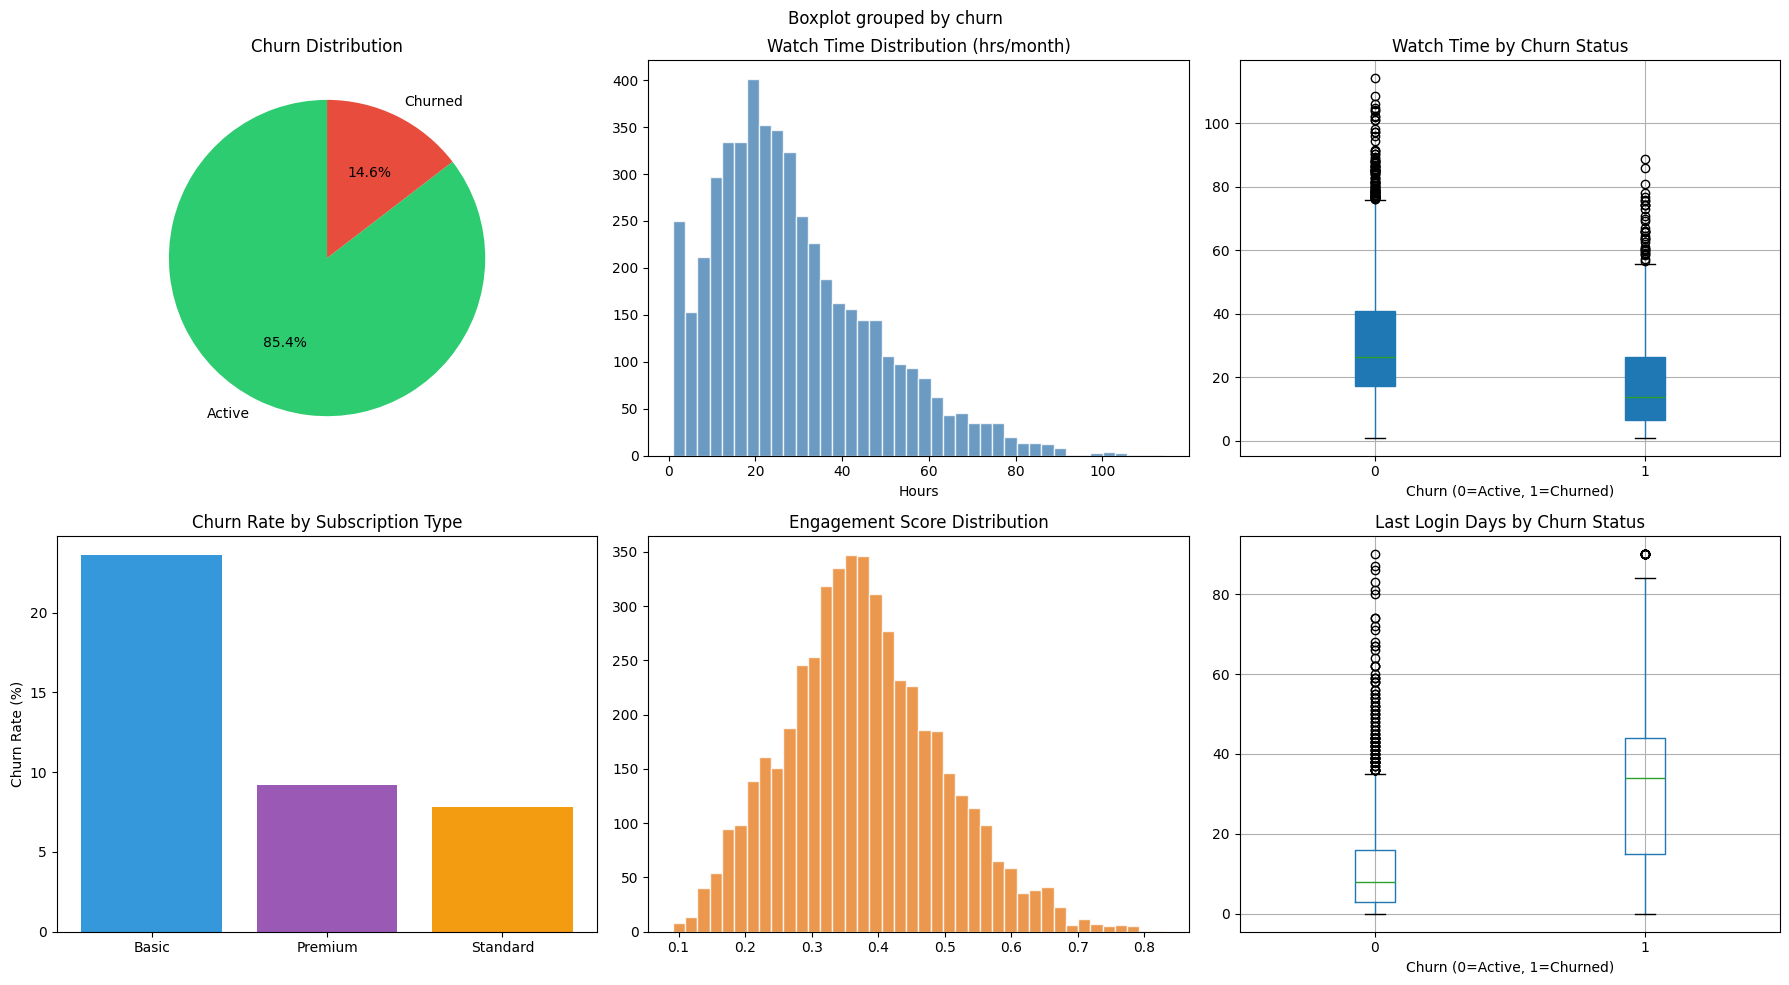

✅ EDA plots rendered.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('OTT Platform - User Behavior EDA', fontsize=16, fontweight='bold')

# 1. Churn Distribution
churn_counts = fe_df['churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['Active', 'Churned'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0,0].set_title('Churn Distribution')

# 2. Watch Time Distribution
axes[0,1].hist(fe_df['watch_time'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Watch Time Distribution (hrs/month)')
axes[0,1].set_xlabel('Hours')

# 3. Watch Time vs Churn
fe_df.boxplot(column='watch_time', by='churn', ax=axes[0,2], patch_artist=True)
axes[0,2].set_title('Watch Time by Churn Status')
axes[0,2].set_xlabel('Churn (0=Active, 1=Churned)')

# 4. Subscription Type vs Churn
sub_churn = fe_df.groupby('subscription_type')['churn'].mean() * 100
axes[1,0].bar(sub_churn.index, sub_churn.values, color=['#3498db', '#9b59b6', '#f39c12'])
axes[1,0].set_title('Churn Rate by Subscription Type')
axes[1,0].set_ylabel('Churn Rate (%)')

# 5. Engagement Score Distribution
axes[1,1].hist(fe_df['engagement_score'], bins=40, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Engagement Score Distribution')

# 6. Last Login Days vs Churn
fe_df.boxplot(column='last_login_days', by='churn', ax=axes[1,2])
axes[1,2].set_title('Last Login Days by Churn Status')
axes[1,2].set_xlabel('Churn (0=Active, 1=Churned)')

plt.tight_layout()
plt.show()
print("✅ EDA plots rendered.")

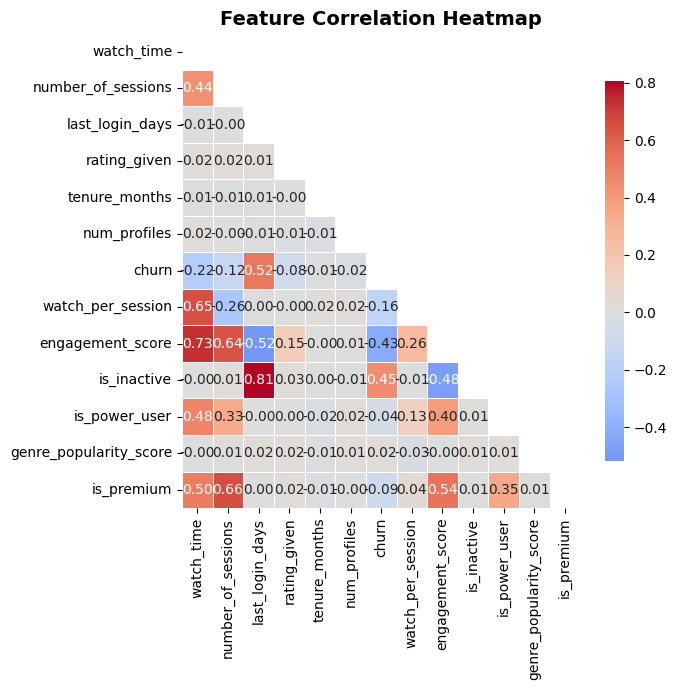

In [8]:
# Correlation Heatmap
numeric_cols = fe_df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = fe_df[numeric_cols].corr()

plt.figure(figsize=(7, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔄 Step 6: Prepare Data for ML Models

In [9]:
ml_df = fe_df.copy()

# Encode categorical features
le = LabelEncoder()
cat_cols = ['subscription_type', 'preferred_genre', 'device_type', 'content_pref', 'loyalty_tier']

for col in cat_cols:
    ml_df[col + '_enc'] = le.fit_transform(ml_df[col].astype(str))

# Select final feature set
feature_cols = [
    'watch_time', 'number_of_sessions', 'last_login_days', 'rating_given',
    'tenure_months', 'num_profiles', 'watch_per_session', 'engagement_score',
    'is_inactive', 'is_power_user', 'genre_popularity_score', 'is_premium',
    'subscription_type_enc', 'preferred_genre_enc', 'device_type_enc',
    'content_pref_enc', 'loyalty_tier_enc'
]

X = ml_df[feature_cols]
y_churn = ml_df['churn']          # Classification target
y_watch = ml_df['watch_time']     # Regression target

print("✅ Feature matrix ready")
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"Churn target: {y_churn.value_counts().to_dict()}")

✅ Feature matrix ready
Features: 17  |  Samples: 5000
Churn target: {0: 4271, 1: 729}


---
# 🟢 TASK 1: CLASSIFICATION — Will the User Churn?
### Algorithms: Logistic Regression | KNN | SVM | Decision Tree | Random Forest

In [10]:
# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# Scale features
scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs = scaler_c.transform(X_test_c)

print(f"Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print(f"Churn rate in test: {y_test_c.mean()*100:.1f}%")

Train: (4000, 17) | Test: (1000, 17)
Churn rate in test: 14.6%


In [11]:
def evaluate_classifier(name, model, X_tr, X_te, y_tr, y_te, use_scaled=True):
    """Train classifier and print metrics."""
    Xtr = X_tr if use_scaled else X_train_c.values
    Xte = X_te if use_scaled else X_test_c.values
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    print(f"\n{'='*55}")
    print(f"  📌 {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['Active', 'Churned']))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}, model, y_pred

clf_results = []

In [12]:
# ---- 1.1 Logistic Regression ----
lr_model = LogisticRegression(max_iter=1000, random_state=42)
res, lr_fitted, lr_pred = evaluate_classifier(
    "Logistic Regression", lr_model,
    X_train_cs, X_test_cs, y_train_c, y_test_c
)
clf_results.append(res)


  📌 Logistic Regression
  Accuracy : 0.9150  (91.50%)
  Precision: 0.8081
  Recall   : 0.5479
  F1 Score : 0.6531

  Classification Report:
              precision    recall  f1-score   support

      Active       0.93      0.98      0.95       854
     Churned       0.81      0.55      0.65       146

    accuracy                           0.92      1000
   macro avg       0.87      0.76      0.80      1000
weighted avg       0.91      0.92      0.91      1000



In [13]:
# ---- 1.2 K-Nearest Neighbors ----
knn_model = KNeighborsClassifier(n_neighbors=7)
res, knn_fitted, knn_pred = evaluate_classifier(
    "K-Nearest Neighbors (K=7)", knn_model,
    X_train_cs, X_test_cs, y_train_c, y_test_c
)
clf_results.append(res)


  📌 K-Nearest Neighbors (K=7)
  Accuracy : 0.8970  (89.70%)
  Precision: 0.7312
  Recall   : 0.4658
  F1 Score : 0.5690

  Classification Report:
              precision    recall  f1-score   support

      Active       0.91      0.97      0.94       854
     Churned       0.73      0.47      0.57       146

    accuracy                           0.90      1000
   macro avg       0.82      0.72      0.76      1000
weighted avg       0.89      0.90      0.89      1000



In [14]:
# ---- 1.3 Support Vector Machine ----
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
res, svm_fitted, svm_pred = evaluate_classifier(
    "Support Vector Machine (RBF)", svm_model,
    X_train_cs, X_test_cs, y_train_c, y_test_c
)
clf_results.append(res)


  📌 Support Vector Machine (RBF)
  Accuracy : 0.9210  (92.10%)
  Precision: 0.8384
  Recall   : 0.5685
  F1 Score : 0.6776

  Classification Report:
              precision    recall  f1-score   support

      Active       0.93      0.98      0.95       854
     Churned       0.84      0.57      0.68       146

    accuracy                           0.92      1000
   macro avg       0.88      0.77      0.82      1000
weighted avg       0.92      0.92      0.91      1000



In [15]:
# ---- 1.4 Decision Tree ----
dt_clf = DecisionTreeClassifier(max_depth=6, random_state=42)
res, dt_fitted, dt_pred = evaluate_classifier(
    "Decision Tree", dt_clf,
    X_train_cs, X_test_cs, y_train_c, y_test_c
)
clf_results.append(res)


  📌 Decision Tree
  Accuracy : 0.9480  (94.80%)
  Precision: 0.7866
  Recall   : 0.8836
  F1 Score : 0.8323

  Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.96      0.97       854
     Churned       0.79      0.88      0.83       146

    accuracy                           0.95      1000
   macro avg       0.88      0.92      0.90      1000
weighted avg       0.95      0.95      0.95      1000



In [16]:
# ---- 1.5 Random Forest ----
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
res, rf_fitted, rf_pred = evaluate_classifier(
    "Random Forest", rf_clf,
    X_train_cs, X_test_cs, y_train_c, y_test_c
)
clf_results.append(res)


  📌 Random Forest
  Accuracy : 0.9440  (94.40%)
  Precision: 0.7922
  Recall   : 0.8356
  F1 Score : 0.8133

  Classification Report:
              precision    recall  f1-score   support

      Active       0.97      0.96      0.97       854
     Churned       0.79      0.84      0.81       146

    accuracy                           0.94      1000
   macro avg       0.88      0.90      0.89      1000
weighted avg       0.95      0.94      0.94      1000




📊 CLASSIFICATION — ALL MODELS COMPARISON
                              Accuracy  Precision    Recall        F1
Model                                                                
Logistic Regression              0.915   0.808081  0.547945  0.653061
K-Nearest Neighbors (K=7)        0.897   0.731183  0.465753  0.569038
Support Vector Machine (RBF)     0.921   0.838384  0.568493  0.677551
Decision Tree                    0.948   0.786585  0.883562  0.832258
Random Forest                    0.944   0.792208  0.835616  0.813333


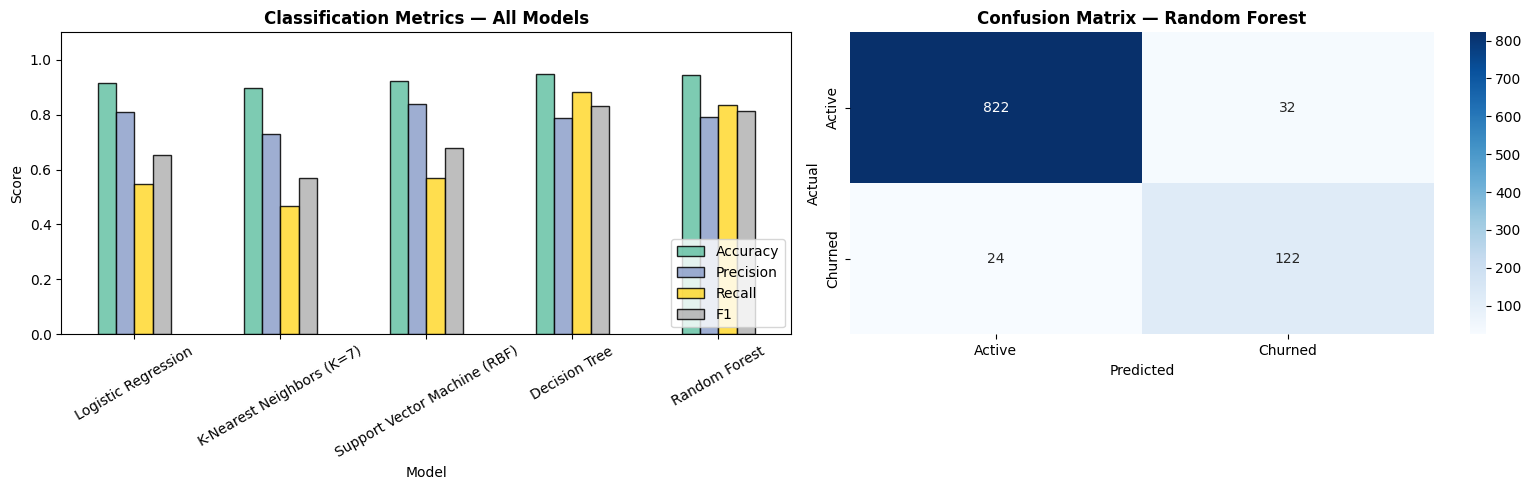

In [17]:
# ---- Classification Results Comparison ----
clf_df = pd.DataFrame(clf_results).set_index('Model')
print("\n📊 CLASSIFICATION — ALL MODELS COMPARISON")
print("=" * 60)
print(clf_df.to_string())

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

clf_df[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='black', alpha=0.85
)
axes[0].set_title('Classification Metrics — All Models', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30)

# Confusion Matrix for best model (Random Forest)
cm = confusion_matrix(y_test_c, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
axes[1].set_title('Confusion Matrix — Random Forest', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

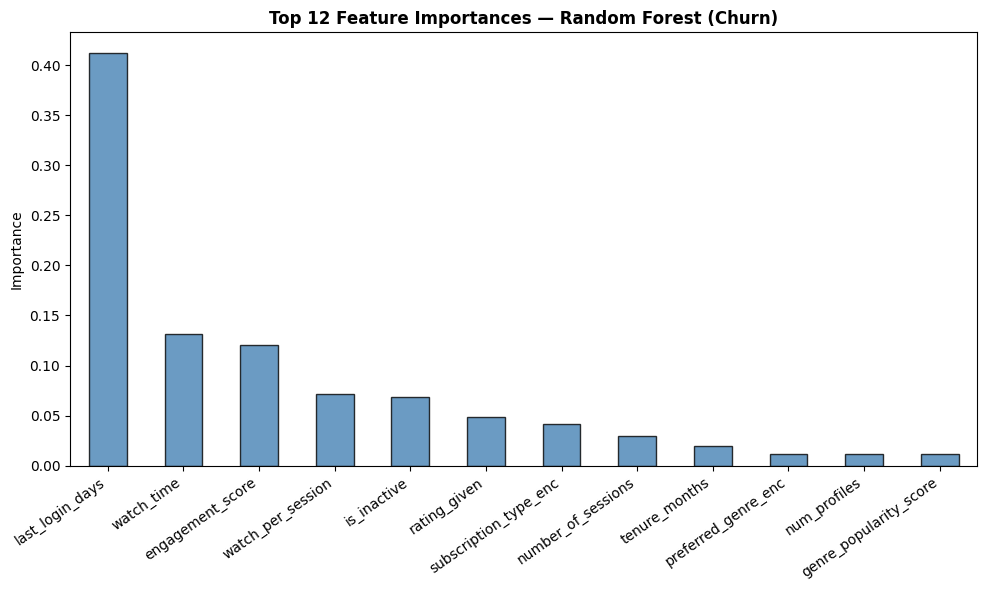


🏆 Top 5 Most Important Features for Churn Prediction:
last_login_days      0.412221
watch_time           0.131537
engagement_score     0.120037
watch_per_session    0.071205
is_inactive          0.069020


In [18]:
# Feature Importance — Random Forest
importances = rf_fitted.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(12).plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Top 12 Feature Importances — Random Forest (Churn)', fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Most Important Features for Churn Prediction:")
print(feat_imp.head(5).to_string())

---
# 🟡 TASK 2: REGRESSION — Predict Watch Time
### Algorithms: Linear Regression | Decision Tree Regressor | Random Forest Regressor

In [19]:
# For regression, use all features EXCEPT watch_time itself
reg_feature_cols = [c for c in feature_cols if c != 'watch_time']

X_reg = ml_df[reg_feature_cols]
y_reg = ml_df['watch_time']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

print(f"Regression Train: {X_train_r.shape} | Test: {X_test_r.shape}")
print(f"Target (watch_time) — Mean: {y_reg.mean():.2f} hrs, Std: {y_reg.std():.2f} hrs")

Regression Train: (4000, 16) | Test: (1000, 16)
Target (watch_time) — Mean: 28.68 hrs, Std: 18.56 hrs


In [20]:
def evaluate_regressor(name, model, Xtr, Xte, ytr, yte):
    """Train regressor and print metrics."""
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    mae  = mean_absolute_error(yte, y_pred)
    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    r2   = r2_score(yte, y_pred)
    print(f"\n{'='*55}")
    print(f"  📌 {name}")
    print(f"{'='*55}")
    print(f"  MAE  (Mean Absolute Error) : {mae:.4f} hrs")
    print(f"  RMSE (Root Mean Sq. Error) : {rmse:.4f} hrs")
    print(f"  R²   (R-Squared Score)     : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2}, model, y_pred

reg_results = []

In [21]:
# ---- 2.1 Linear Regression ----
lr_reg = LinearRegression()
res, lr_reg_fitted, lr_reg_pred = evaluate_regressor(
    "Linear Regression", lr_reg,
    X_train_rs, X_test_rs, y_train_r, y_test_r
)
reg_results.append(res)


  📌 Linear Regression
  MAE  (Mean Absolute Error) : 3.5881 hrs
  RMSE (Root Mean Sq. Error) : 4.7189 hrs
  R²   (R-Squared Score)     : 0.9295


In [22]:
# ---- 2.2 Decision Tree Regressor ----
dt_reg = DecisionTreeRegressor(max_depth=8, random_state=42)
res, dt_reg_fitted, dt_reg_pred = evaluate_regressor(
    "Decision Tree Regressor", dt_reg,
    X_train_rs, X_test_rs, y_train_r, y_test_r
)
reg_results.append(res)


  📌 Decision Tree Regressor
  MAE  (Mean Absolute Error) : 2.3313 hrs
  RMSE (Root Mean Sq. Error) : 3.4616 hrs
  R²   (R-Squared Score)     : 0.9620


In [23]:
# ---- 2.3 Random Forest Regressor ----
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
res, rf_reg_fitted, rf_reg_pred = evaluate_regressor(
    "Random Forest Regressor", rf_reg,
    X_train_rs, X_test_rs, y_train_r, y_test_r
)
reg_results.append(res)


  📌 Random Forest Regressor
  MAE  (Mean Absolute Error) : 0.8141 hrs
  RMSE (Root Mean Sq. Error) : 1.6446 hrs
  R²   (R-Squared Score)     : 0.9914



📊 REGRESSION — ALL MODELS COMPARISON
                              MAE      RMSE        R²
Model                                                
Linear Regression        3.588120  4.718880  0.929475
Decision Tree Regressor  2.331341  3.461629  0.962049
Random Forest Regressor  0.814066  1.644579  0.991434


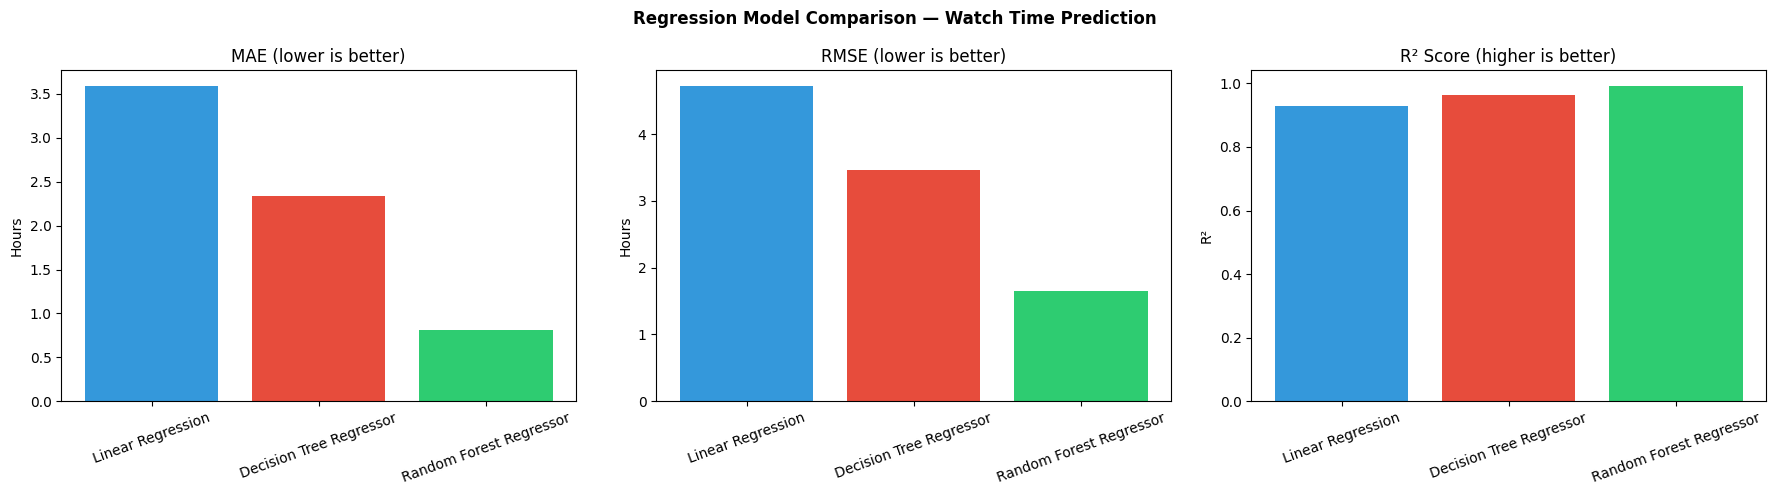

In [24]:
# ---- Regression Results Comparison ----
reg_df = pd.DataFrame(reg_results).set_index('Model')
print("\n📊 REGRESSION — ALL MODELS COMPARISON")
print("=" * 55)
print(reg_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regression Model Comparison — Watch Time Prediction', fontweight='bold')

# MAE bar
axes[0].bar(reg_df.index, reg_df['MAE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('Hours')
axes[0].tick_params(axis='x', rotation=20)

# RMSE bar
axes[1].bar(reg_df.index, reg_df['RMSE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('Hours')
axes[1].tick_params(axis='x', rotation=20)

# R² bar
axes[2].bar(reg_df.index, reg_df['R²'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('R² Score (higher is better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

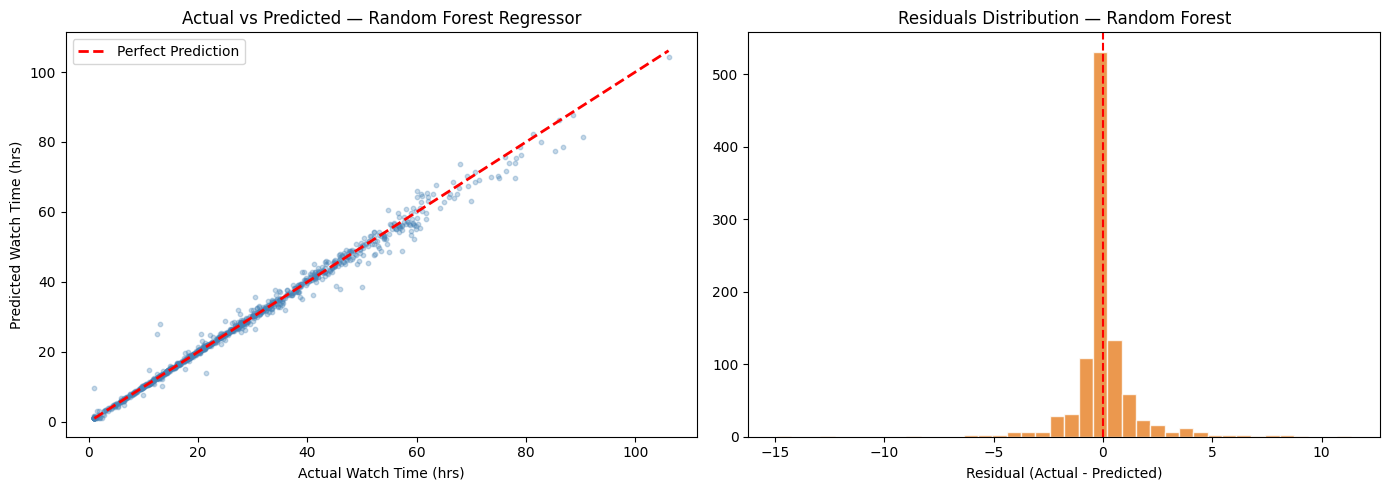

In [25]:
# Actual vs Predicted — Random Forest Regressor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test_r, rf_reg_pred, alpha=0.3, color='steelblue', s=10)
lims = [y_test_r.min(), y_test_r.max()]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Watch Time (hrs)')
axes[0].set_ylabel('Predicted Watch Time (hrs)')
axes[0].set_title('Actual vs Predicted — Random Forest Regressor')
axes[0].legend()

# Residuals
residuals = y_test_r - rf_reg_pred
axes[1].hist(residuals, bins=40, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution — Random Forest')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

---
# 🔵 TASK 3: CLUSTERING — Viewer Personas
### Algorithms: K-Means | Hierarchical (Agglomerative) Clustering

In [26]:
# Select clustering features (behavior-based, not labels)
cluster_features = [
    'watch_time', 'number_of_sessions', 'last_login_days',
    'rating_given', 'watch_per_session', 'engagement_score',
    'tenure_months', 'num_profiles'
]

X_clust = ml_df[cluster_features].copy()

scaler_cl = MinMaxScaler()
X_clust_scaled = scaler_cl.fit_transform(X_clust)

print(f"Clustering feature matrix: {X_clust_scaled.shape}")

Clustering feature matrix: (5000, 8)


K=2 | Inertia: 1283 | Silhouette: 0.2063
K=3 | Inertia: 1071 | Silhouette: 0.1960
K=4 | Inertia: 963 | Silhouette: 0.1834
K=5 | Inertia: 872 | Silhouette: 0.1860
K=6 | Inertia: 826 | Silhouette: 0.1800
K=7 | Inertia: 784 | Silhouette: 0.1783
K=8 | Inertia: 749 | Silhouette: 0.1673
K=9 | Inertia: 718 | Silhouette: 0.1581


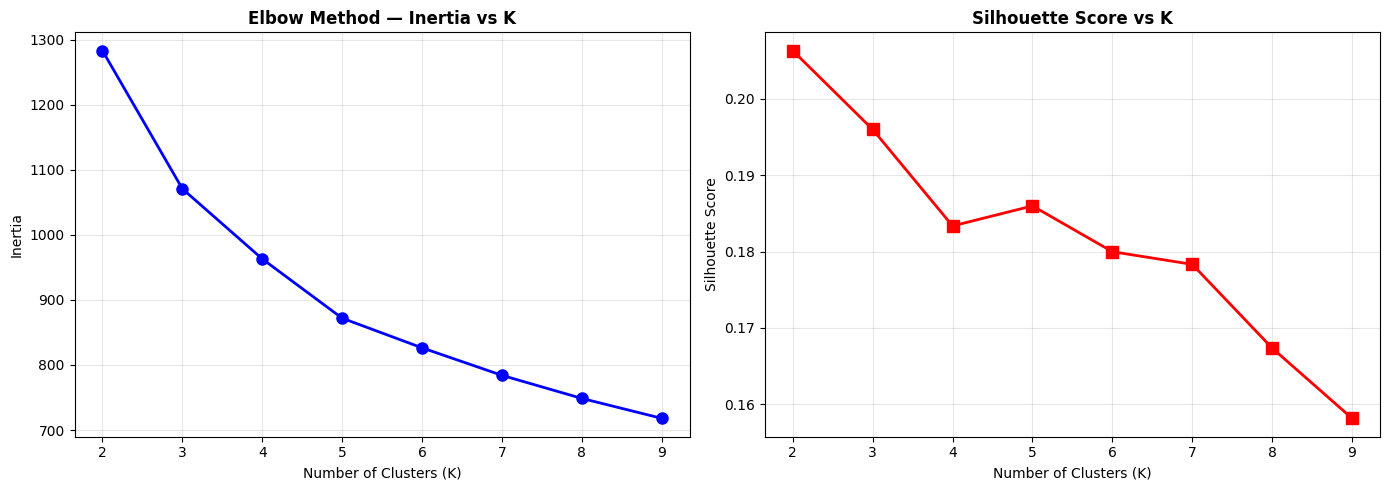


✅ Best K by Silhouette: 2 (Score: 0.2063)


In [27]:
# ---- 3.1 Elbow Method — Find optimal K for K-Means ----
inertias = []
silhouette_scores_k = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust_scaled, km.labels_)
    silhouette_scores_k.append(sil)
    print(f"K={k} | Inertia: {km.inertia_:.0f} | Silhouette: {sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouette_scores_k, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouette_scores_k)]
print(f"\n✅ Best K by Silhouette: {best_k} (Score: {max(silhouette_scores_k):.4f})")

In [28]:
# ---- 3.2 Apply K-Means with best K ----
OPTIMAL_K = 4  # We fix at 4 for interpretable viewer personas

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clust_scaled)

ml_df['kmeans_cluster'] = kmeans_labels

sil_kmeans = silhouette_score(X_clust_scaled, kmeans_labels)
print(f"\n📊 K-Means Clustering (K={OPTIMAL_K})")
print(f"   Silhouette Score: {sil_kmeans:.4f}")
print(f"\n   Cluster Sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index().to_string())


📊 K-Means Clustering (K=4)
   Silhouette Score: 0.1834

   Cluster Sizes:
0    1544
1     954
2    1054
3    1448


In [29]:
# Analyze cluster characteristics to assign viewer personas
cluster_profile = ml_df.groupby('kmeans_cluster')[cluster_features].mean().round(2)
print("\n📊 Cluster Profiles (Mean Values):")
print(cluster_profile.to_string())

# Assign persona names based on feature values
def assign_persona(row):
    if row['watch_time'] > 60 and row['number_of_sessions'] > 20:
        return '🍿 Binge Watcher'
    elif row['last_login_days'] > 25:
        return '😴 Lapsed Viewer'
    elif row['watch_time'] < 20 and row['number_of_sessions'] < 8:
        return '😌 Casual Viewer'
    else:
        return '📅 Regular Viewer'

persona_map = {idx: assign_persona(row) for idx, row in cluster_profile.iterrows()}
print("\n🎭 Persona Assignment:")
for k, v in persona_map.items():
    print(f"   Cluster {k} → {v}")

ml_df['persona'] = ml_df['kmeans_cluster'].map(persona_map)


📊 Cluster Profiles (Mean Values):
                watch_time  number_of_sessions  last_login_days  rating_given  watch_per_session  engagement_score  tenure_months  num_profiles
kmeans_cluster                                                                                                                                 
0                    28.66               11.17            14.27          3.48               2.55              0.38          44.34          1.52
1                    28.74               11.23            14.59          3.45               2.53              0.38          45.18          3.63
2                    29.16               11.41            13.69          3.50               2.51              0.38          15.51          3.63
3                    28.32               11.60            14.59          3.48               2.44              0.38          15.19          1.50

🎭 Persona Assignment:
   Cluster 0 → 📅 Regular Viewer
   Cluster 1 → 📅 Regular Viewer
   Cluster 2 →

In [30]:
# ---- 3.3 Hierarchical Clustering ----
# Use a subset for performance
sample_idx = np.random.choice(len(X_clust_scaled), size=1000, replace=False)
X_hier_sample = X_clust_scaled[sample_idx]

hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels_sample = hc.fit_predict(X_hier_sample)

sil_hier = silhouette_score(X_hier_sample, hier_labels_sample)
print(f"\n📊 Hierarchical Clustering (Agglomerative, K={OPTIMAL_K})")
print(f"   Silhouette Score: {sil_hier:.4f}")
print(f"\n   Cluster Sizes (sample of 1000):")
print(pd.Series(hier_labels_sample).value_counts().sort_index().to_string())


📊 Hierarchical Clustering (Agglomerative, K=4)
   Silhouette Score: 0.1231

   Cluster Sizes (sample of 1000):
0    320
1    402
2    142
3    136


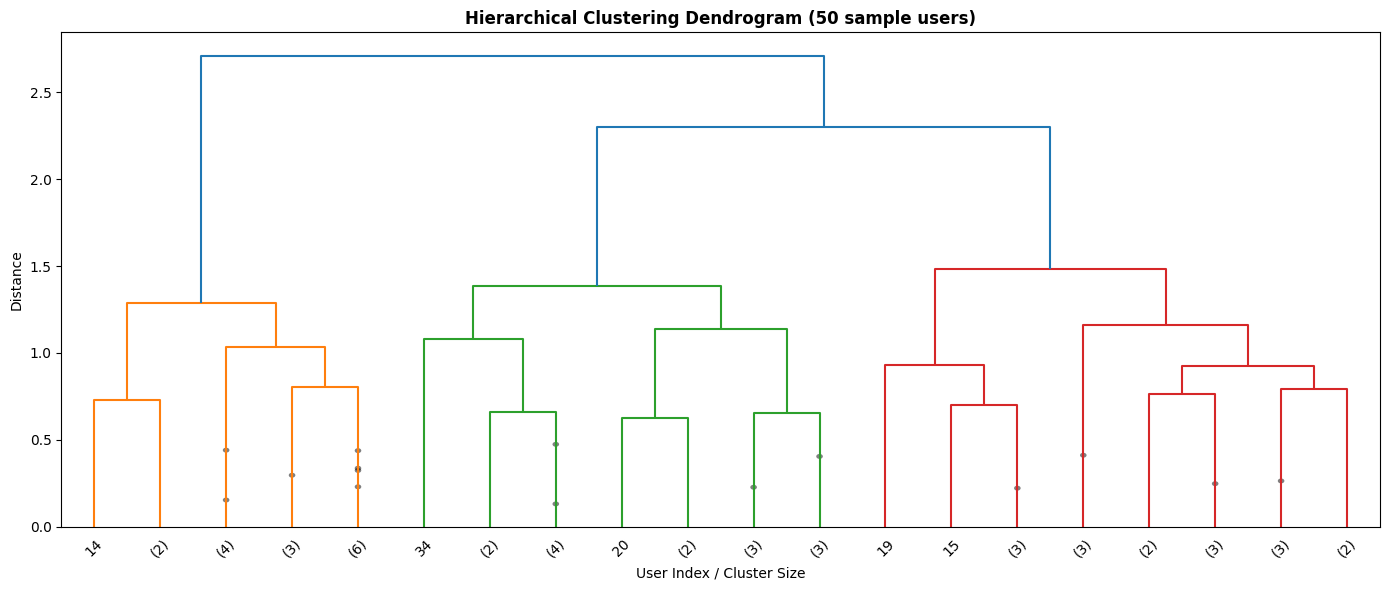


📊 Silhouette Score Comparison:
   K-Means          : 0.1834
   Hierarchical (HC): 0.1231


In [31]:
# Dendrogram (subset of 50 for visual clarity)
X_dendro = X_clust_scaled[:50]
linked = linkage(X_dendro, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (50 sample users)', fontweight='bold')
plt.xlabel('User Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

print(f"\n📊 Silhouette Score Comparison:")
print(f"   K-Means          : {sil_kmeans:.4f}")
print(f"   Hierarchical (HC): {sil_hier:.4f}")

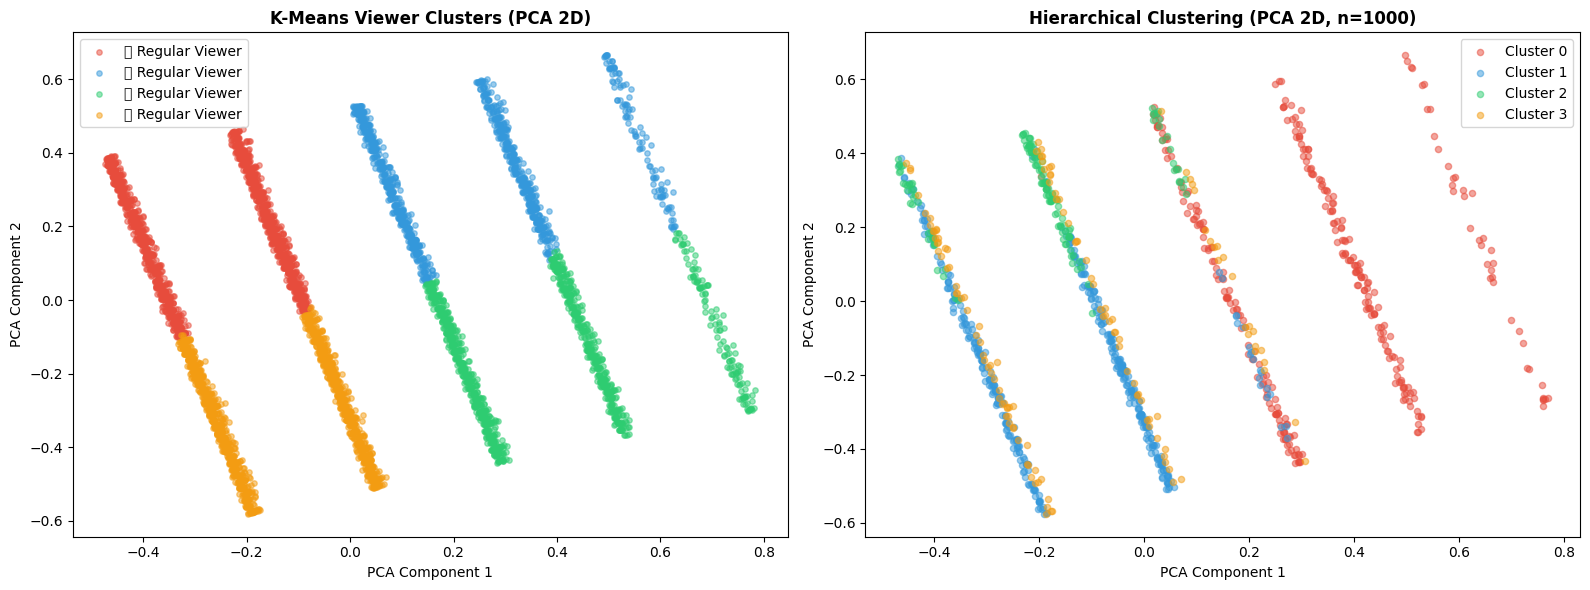

In [32]:
# Visualize Clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
personas = [persona_map.get(i, f'Cluster {i}') for i in range(OPTIMAL_K)]

# K-Means visualization
for cluster_id in range(OPTIMAL_K):
    mask = kmeans_labels == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cluster_id], label=personas[cluster_id],
                    alpha=0.5, s=15)
axes[0].set_title('K-Means Viewer Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()

# Hierarchical visualization (sample)
X_pca_sample = X_pca[sample_idx]
for cluster_id in range(OPTIMAL_K):
    mask = hier_labels_sample == cluster_id
    axes[1].scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
                    c=colors[cluster_id], label=f'Cluster {cluster_id}',
                    alpha=0.5, s=20)
axes[1].set_title('Hierarchical Clustering (PCA 2D, n=1000)', fontweight='bold')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].legend()

plt.tight_layout()
plt.show()


🎭 VIEWER PERSONA SUMMARY
                  Count  Avg_Watch_Time  Avg_Sessions  Avg_Last_Login  Avg_Rating Churn_Rate
persona                                                                                     
📅 Regular Viewer   5000           28.68         11.35            14.3        3.48      15.0%


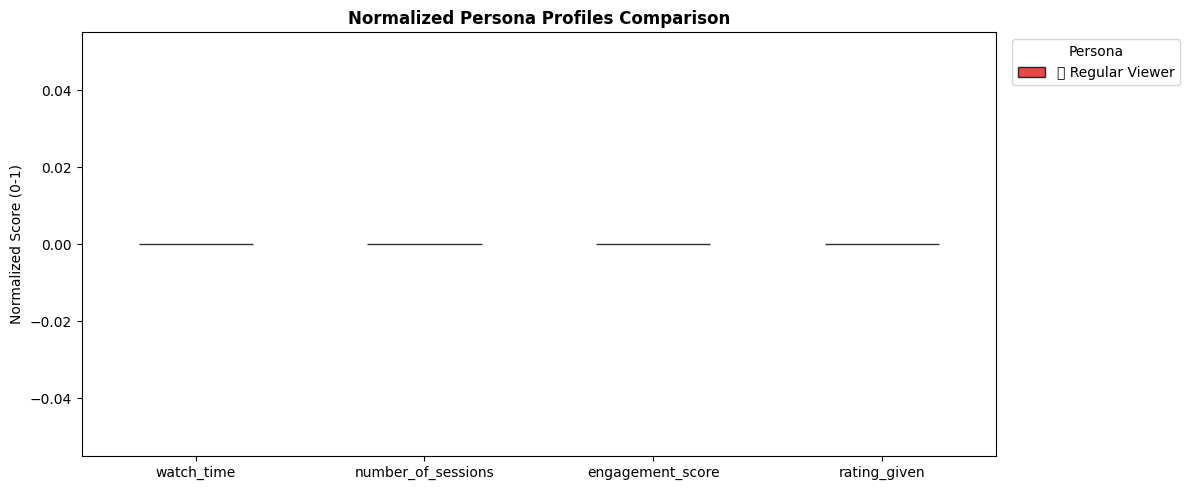

In [33]:
# Persona Profile Summary
persona_summary = ml_df.groupby('persona').agg(
    Count=('user_id', 'count'),
    Avg_Watch_Time=('watch_time', 'mean'),
    Avg_Sessions=('number_of_sessions', 'mean'),
    Avg_Last_Login=('last_login_days', 'mean'),
    Avg_Rating=('rating_given', 'mean'),
    Churn_Rate=('churn', 'mean')
).round(2)

persona_summary['Churn_Rate'] = (persona_summary['Churn_Rate'] * 100).round(1).astype(str) + '%'

print("\n🎭 VIEWER PERSONA SUMMARY")
print("=" * 80)
print(persona_summary.to_string())

# Radar chart style bar plot
radar_df = ml_df.groupby('persona')[['watch_time','number_of_sessions','engagement_score','rating_given']].mean()

radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())  # normalize 0-1

ax = radar_norm.T.plot(kind='bar', figsize=(12, 5), colormap='Set1', edgecolor='black', alpha=0.8)
plt.title('Normalized Persona Profiles Comparison', fontweight='bold')
plt.ylabel('Normalized Score (0-1)')
plt.xticks(rotation=0)
plt.legend(title='Persona', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
# 📋 Final Summary Report

In [37]:
print("=" * 65)
print("   🎬 OTT PLATFORM USER BEHAVIOR ANALYZER — FINAL REPORT")
print("=" * 65)

print("\n📌 DATASET")
print(f"   Netflix Content Rows : {netflix_df.shape[0]}")
print(f"   Simulated Users      : {N_USERS}")
print(f"   Features Engineered  : {len(feature_cols)}")
print(f"   Overall Churn Rate   : {user_df['churn'].mean()*100:.1f}%")

print("\n🟢 TASK 1 — CLASSIFICATION (Churn Prediction)")
print("-" * 55)
print(clf_df[['Accuracy','Precision','Recall','F1']].to_string())
best_clf = clf_df['F1'].idxmax()
print(f"\n   🏆 Best Classifier by F1: {best_clf} ({clf_df.loc[best_clf,'F1']:.4f})")

print("\n🟡 TASK 2 — REGRESSION (Watch Time Prediction)")
print("-" * 55)
print(reg_df[['MAE','RMSE','R²']].to_string())
best_reg = reg_df['R²'].idxmax()
print(f"\n   🏆 Best Regressor by R²: {best_reg} ({reg_df.loc[best_reg,'R²']:.4f})")

print("\n🔵 TASK 3 — CLUSTERING (Viewer Personas)")
print("-" * 55)
print(f"   Algorithm        : K-Means + Agglomerative Hierarchical")
print(f"   Optimal K        : {OPTIMAL_K}")
print(f"   K-Means Silhouette   : {sil_kmeans:.4f}")
print(f"   HC Silhouette        : {sil_hier:.4f}")
print(f"\n   Viewer Personas Identified:")
for k, v in persona_map.items():
    count = (ml_df['kmeans_cluster'] == k).sum()
    print(f"      Cluster {k}: {v} — {count} users")

print("\n⭐ BONUS — Recommendation System")
print("-" * 55)
print("   Type: Content-Based Filtering (TF-IDF + Cosine Similarity)")
print("   Works on: Genre, Type, Rating, Description")

print("\n" + "=" * 65)
print("   ✅ All Tasks Complete!")
print("=" * 65)

   🎬 OTT PLATFORM USER BEHAVIOR ANALYZER — FINAL REPORT

📌 DATASET
   Netflix Content Rows : 8807
   Simulated Users      : 5000
   Features Engineered  : 17
   Overall Churn Rate   : 14.6%

🟢 TASK 1 — CLASSIFICATION (Churn Prediction)
-------------------------------------------------------
                              Accuracy  Precision    Recall        F1
Model                                                                
Logistic Regression              0.915   0.808081  0.547945  0.653061
K-Nearest Neighbors (K=7)        0.897   0.731183  0.465753  0.569038
Support Vector Machine (RBF)     0.921   0.838384  0.568493  0.677551
Decision Tree                    0.948   0.786585  0.883562  0.832258
Random Forest                    0.944   0.792208  0.835616  0.813333

   🏆 Best Classifier by F1: Decision Tree (0.8323)

🟡 TASK 2 — REGRESSION (Watch Time Prediction)
-------------------------------------------------------
                              MAE      RMSE        R²
Model    